# Péndulos acoplados
Para el límite de péndulos continuos, trabajamos con la ecuación de sine-Gordon:
\begin{equation}
\frac{1}{c^2}\frac{\partial^2\theta}{\partial t^2} - \nabla^2\theta = sin\theta
\end{equation}
Que puede ser extendida a un campo $u(x, t)$.
Resolviendo para una dimensión:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

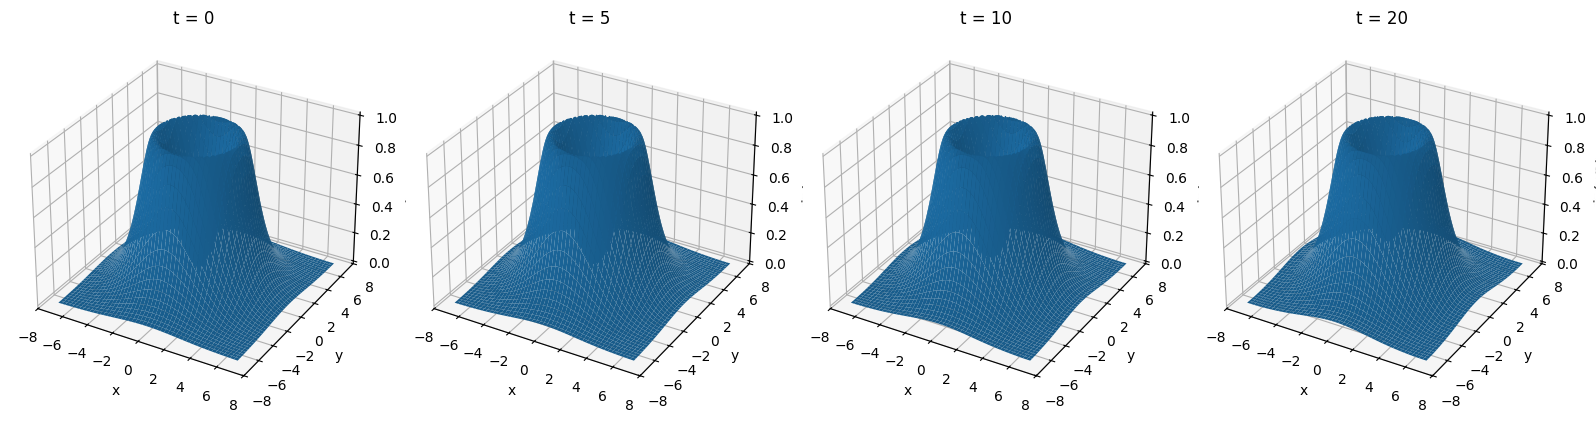

In [6]:
#Parámetros
N = 201
L = 14.0
dx = L / N
dt = dx / np.sqrt(2) #condición de estabilidad tipo CFL
stepts_to_plot = [0, 5, 10, 20]

#malla
x = np.linspace(- L / 2, L / 2, N)
y = np.linspace(- L / 2, L / 2, N)
X, Y = np.meshgrid(x, y)

#variables
u = np.zeros((N, N))
u_prev = np.zeros((N, N))
u_next = np.zeros((N, N))

#condición inicial (ring soliton)
R = np.sqrt(X ** 2 + Y ** 2)
u = 4 * np.arctan(np.exp(3 - R))
u_prev = np.copy(u)

# Función laplaciano
def laplacian(u):
    return(
        np.roll(u, 1, axis = 0) +
        np.roll(u, -1, axis = 0) +
        np.roll(u, 1, axis = 1) + 
        np.roll(u, -1, axis = 1)
        - 4 * u
    ) / dx ** 2

# Evolución temporal
snapshots = []

for t in range(max(stepts_to_plot) + 1):

    #Guardar snpashots
    if t in stepts_to_plot:
        snapshots.append(np.sin(u / 2))

    #Esquema leapfrog

    u_next = (2 * u - u_prev + dt ** 2 * (laplacian(u) - np.sin(u)))

    #condiciones de frontera simple (Newumann)
    u_next[0, : ] = u_next[1, :]
    u_next[-1, :] = u_next[-2, :]
    u_next[:, 0] = u_next[:, 1]
    u_next[:, -1] = u_next[:, -2]

    #Avanzar
    u_prev = np.copy(u)
    u = np.copy(u_next)

#Graficas 3D tipo fig 4.9
fig = plt.figure(figsize = (16, 4))

for i, snap in enumerate(snapshots):
    ax = fig.add_subplot(1, len(snapshots), i + 1, projection = '3d')
    
    ax.plot_surface(X, Y, snap, rstride = 4, cstride = 4)
    ax.set_title(f"t = {stepts_to_plot[i]}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("sin(u/2)")

plt.tight_layout()
plt.show()

# Hidrodinámica
Basada en la ecuación de continuidad:
\begin{equation}
\frac{\partial\rho}{\partial t} + \nabla \cdot \vec{j} = 0;\qquad \vec{j} = \rho\vec{v}
\end{equation}
Y cuya dinámica está descrita por la ecuación de Navier-Stokes:
\begin{equation}
\frac{D \vec{v}}{D t} = \nu\nabla^2\vec{v}-\frac{1}{\rho}\nabla P; \qquad \frac{D\vec{v}}{Dt} = \frac{\partial \vec{v}}{\partial t} + (\vec{v}\cdot\nabla)\vec{v}
\end{equation}


## Caso 2D
$$\frac{\partial vx}{\partial x} + \frac{\partial vy}{\partial y} = 0$$
$$
\nu\nabla^2 v_{x_i} = v_{x_i}\frac{\partial v_{x_i}}{\partial x} + v_{x_j}\frac{\partial v_{x_i}}{\partial y}
$$
Trabajamos una viga sumergida, la cual tiene las condiciones:
- Entrada: $u = V_o y$
- Salida: $\frac{\partial u}{\partial x} = 0$
- Superficie: $\frac{\partial u}{\partial y} = 0$
- Línea central: $u = 0$
- Viga: $u = 0$

Las condiciones para la vorticidad w:
- Entrada y salida: $w = 0$
- Superficie: $w = 0$
- Viga:
$$w = -\frac{2}{h^2}(u_{vecino} - u)$$

C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_7836\4294252973.py:19: RuntimeWarning: overflow encountered in scalar add
  vx[i + 1, j] + vx[i - 1, j] +
C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_7836\4294252973.py:21: RuntimeWarning: overflow encountered in scalar multiply
  - 4 * vx[i, j]
C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_7836\4294252973.py:19: RuntimeWarning: invalid value encountered in scalar subtract
  vx[i + 1, j] + vx[i - 1, j] +
C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_7836\4294252973.py:28: RuntimeWarning: overflow encountered in scalar multiply
  vx[i, j] = vx[i, j] + omega * r
C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_7836\4294252973.py:28: RuntimeWarning: overflow encountered in scalar add
  vx[i, j] = vx[i, j] + omega * r


Text(0.5, 1.0, 'Flujo (aproximación Navier-Stokes)')

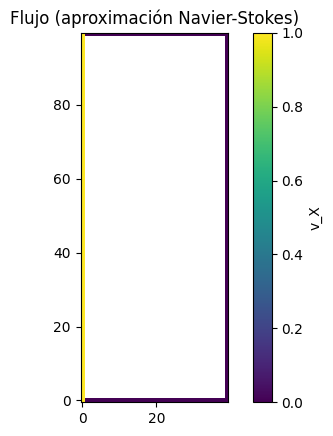

In [10]:
#Parámetros
Nx, Ny = 100, 40
h = 1.0
omega = 1.5 #sobrerrelajación

#Campos
vx = np.zeros((Nx, Ny))
P = np.zeros((Nx, Ny))

#condición de frontera
vx[:, 0] = 1.0

#Iteraciones
for iteration in range(500):
    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):

            laplace = (
                vx[i + 1, j] + vx[i - 1, j] +
                vx[i, j + 1] + vx[i, j - 1]
                - 4 * vx[i, j]
            ) / h ** 2

            #Residual sample
            r = laplace - (P[i + 1, j] - P[i - 1, j]) / (2 * h)

            #Actualización SOR
            vx[i, j] = vx[i, j] + omega * r

#visualización
plt.imshow(vx, origin = 'lower')
plt.colorbar(label = r'v_X')
plt.title("Flujo (aproximación Navier-Stokes)")

# Algoritmo SOR
Se espera que la solución sea independiente del tiempo, pero esto no puede ser implementado al 100%:
$$\phi^{new}_{i,j} - \phi^{old}_{i,j} = \omega r_{i,j}$$
Se clasifca a $\omega$:
- $\omega = 1\rightarrow$ relajación simple
- $1<\omega<2\rightarrow$ sobre-relajación
- $\omega > 2\rightarrow$ inestable
Para el algoritmo:
\begin{equation}
r = \frac{1}{4}(v_{i+1,j}^x+v_{i-1,j}^x + v_{i,j+1}^x + u_{i, j-1} + ...) + ...
\end{equation}

Problema: Viga sumergida

In [16]:
#Parámetros
nu = 1.0
rho = 1e3
Nx = 100
Ny = 100
h = 0.1
omega = 0.1
v0 = 1.0

u = np.zeros((Nx + 1, Ny + 1))
w = np.zeros((Nx + 1, Ny + 1))

In [17]:
def boundary():
    #Inicializacion
    for i in range(Nx + 1):
        for j in range(Ny + 1):
            w[i, j] = 0.0
            u[i, j] = 0.0

    #superficie
    for i in range(1, Nx):
        u[i, Ny] = u[i, Ny - 1] + v0 * h
        w[i, Ny] = 0.0

    #entrada
    for j in range(1, Ny):
        u[0, j] = u[1, j]
        w[0, j] = 0.0

    #salida
    for j in range(1, Ny):
        u[Nx, j] = u[Nx - 1, j]
        w[Nx, j] = w[Nx - 1, j]

def relax():
    for i in range(1, Nx):
        for j in range(1, Ny):
            r1 = omega * ( (
                u[i + 1, j] + u[i -1, j] + u[i, j + 1] + u[i, j - 1] - 4 * u[i, j])
            + h * h * w[i, j]
            )
            u[i, j] += r1

    for i in range(1, Nx):
        for j in range(1, Ny):
            a1 = w[i + 1, j] + w[i - 1, j] + w[i, j + 1] + w[i, j - 1]
            w[i, j] = 0.25 * a1

In [18]:
#iteracion
boundary()
for it in range(100):
    relax()
    if it % 10 == 0:
        print("Iteration: ", it)

Iteration:  0
Iteration:  10
Iteration:  20
Iteration:  30
Iteration:  40
Iteration:  50
Iteration:  60
Iteration:  70
Iteration:  80
Iteration:  90


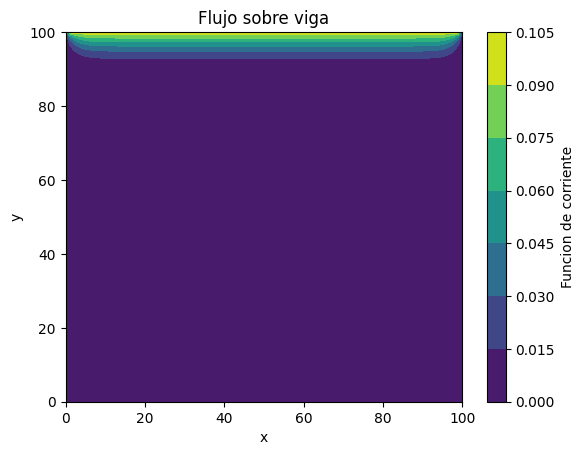

In [19]:
#visualizacion
X, Y = np.meshgrid(range(Nx + 1), range(Ny + 1))
plt.contourf(X, Y, u.T)
plt.colorbar(label = "Funcion de corriente")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Flujo sobre viga")
plt.show()

# Aplicando potenciales de vorticidad:
$$v_{x_i} = \frac{\partial u}{\partial x_i};\qquad \nabla \vec{v} = 0$$
Definimos la vorticidad como la rotación local del fluído:
$$\vec{w} = \nabla\times\vec{v}$$
De manera que tomaremos el rotacial de la ecuación de Navier-Stokes, de manera que el término de presión desaparece gracias a :
$$\nabla\times(\nabla P) = 0$$
La ecuación final toma la siguiente forma:
$$\nu\nabla^2w = \frac{\partial u}{\partial y}\frac{\partial w}{\partial x} - \frac{\partial u}{\partial x}\frac{\partial w}{\partial y}$$
En el caso bidimensional, tenemos las llamadas \textbf{líneas de corriente} o curvas de nivel, definidas como curvas en las cuales:
$$u = cte$$

# Analogía con electrostática
La ecuación
$$\nabla^2 u = -w$$
Es análogo a la ecaución de Poisson en electrostática:
$$\nabla^2\phi = -4\pi\rho$$
De manera que la vorticidad es una fuente de la función de corriente. La forma de vorticidad se obtiene:
$$\nu\nabla^2w = [(\nabla\times u)\cdot\nabla]w$$
Obteniendo las ecuaciones acopladas:
$$\frac{\partial^2u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = -w$$
$$\nu\left(\frac{\partial^2w}{\partial x^2} + \frac{\partial^2w}{\partial y^2}\right) = \frac{\partial u}{\partial y}\frac{\partial w}{\partial x} + \frac{\partial w}{\partial y}\frac{\partial u}{\partial x}$$

In [25]:
#Parametros
Nx = 70
Ny = 24

L_beam = 12
H_beam = 1

V0 = 1.0
R = 0.1

omega = 0.3

max_iter = 5000
tol = 1e-3

#campos
u = np.zeros((Nx, Ny))
w = np.zeros((Nx, Ny))

#posiciones de viga

x0 = 20
x1 = x0 + L_beam

y0 = Ny // 2 - H_beam // 2
y1 = y0 + H_beam

def boundary_conditions():
    #Entrada
    for j in range(Ny):
        u[0, j] = V0 * j

    #Salida
    u[-1, :] = u[-2, :]
    w[-1, :] = w[-2, :]

    #Superficie superior
    u[:, -1] = V0 * (Ny - 1)

    #Inferior
    u[:, 0] = 0

    #Viga
    u[x0 : x1, y0 : y1] = u[x0, y0]

def relax():

    max_residual = 0

    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):

            #Saltar interior de la viga
            if x0 <= i < x1 and y0 <= j < y1:
                continue

            u_new = 0.25 * (
                u[i + 1, j] + u[i - 1, j] +
                u[i, j + 1] + u[i, j - 1] +
                w[i, j])
            
            ru = u_new - u[i,j]

            u[i, j] += omega * ru

            a1 = w[i + 1, j] + w[i - 1, j]
            a2 = w[i, j + 1] + w[i, j - 1]

            a3 = (R / 4.0) * ((u[i, j + 1] - u[i, j - 1]) * 
                              (w[i + 1, j] - w[i - 1, j]) - (u[i + 1, j] - u[i - 1, j]) *
                              (w[i, j + 1] - w[i, j - 1]))
            
            w_new = 0.25 * (a1 + a2 - a3)

            rw = w_new - w[i, j]

            w[i, j] += omega * rw

            max_residual = max(
                max_residual,
                abs(ru),
                abs(rw)
            )
    return max_residual
            

# Relajación simple
$$\omega = 0$$
# Sobrerrelajación
$$\omega \approx 0.3$$

In [26]:
for it in range(max_iter):
    boundary_conditions()

    residual = relax()

    if it % 100 == 0:
        
        print(f'Iteracion {it}')

        print(
            'u upstream = ', u[x0 - 5, Ny // 2]
        )

        print(
            'u arriba = ', u[x0 + L_beam // 2, y1 + 2]
        )

        print(
            'u downstream = ', u[x1 + 5, Ny // 2]
        )

        print('Residual = ', residual)
        print('-----------------------------------------------')

    if residual < tol:
        print('Convergencia alcanzada')
        break

Iteracion 0
u upstream =  4.640493110482402e-16
u arriba =  5.4133584251469535e-28
u downstream =  1.3044368470859686e-40
Residual =  11.674032140248357
-----------------------------------------------
Iteracion 100
u upstream =  0.2006599738942624
u arriba =  1.2502528984049175
u downstream =  0.1924927293169047
Residual =  0.23554240064948306
-----------------------------------------------
Iteracion 200
u upstream =  1.5157421508253444
u arriba =  3.630576617038477
u downstream =  1.3947305662449843
Residual =  0.11179779750256102
-----------------------------------------------
Iteracion 300
u upstream =  3.0795695480276
u arriba =  5.01035998289328
u downstream =  2.7832258381883426
Residual =  0.07044327218582591
-----------------------------------------------
Iteracion 400
u upstream =  4.366714735059388
u arriba =  5.744023830653282
u downstream =  3.939291528680406
Residual =  0.04771471611014544
-----------------------------------------------
Iteracion 500
u upstream =  5.330337

# Visualziación
Los objetos a visualizar:
- Función de corriente $u(x,y)$
- Vorticidad $w(x,y)$
- Curvas de nivel
- Superficies 3D

In [28]:
vx = np.zeros_like(u)
vy = np.zeros_like(u)

vx[:, 1 : -1] = (u[:, 2 :] - u[:, : - 2]) / 2
vy[1 : - 1, :] = -(u[2 :, :] - u[: - 2, :]) / 2

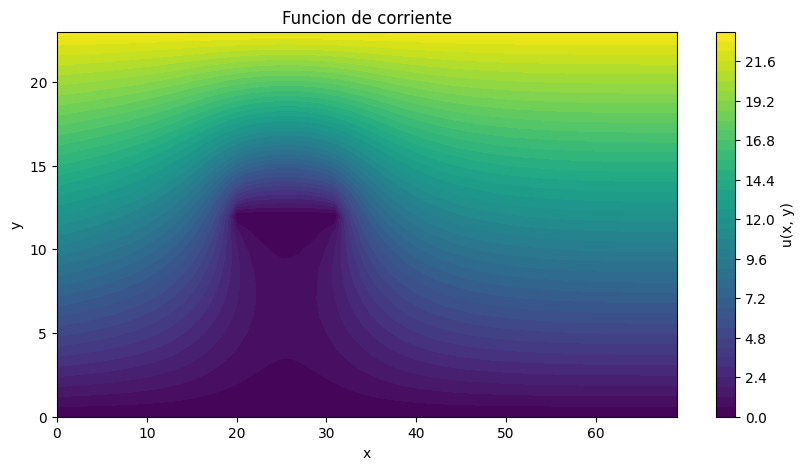

In [29]:
X, Y = np.meshgrid(np.arange(Nx), np.arange(Ny))

plt.figure(figsize = (10, 5))

plt.contourf(
    X, Y, u.T,
    levels = 40
)

plt.colorbar(label = r'u(x, y)')

plt.title('Funcion de corriente')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

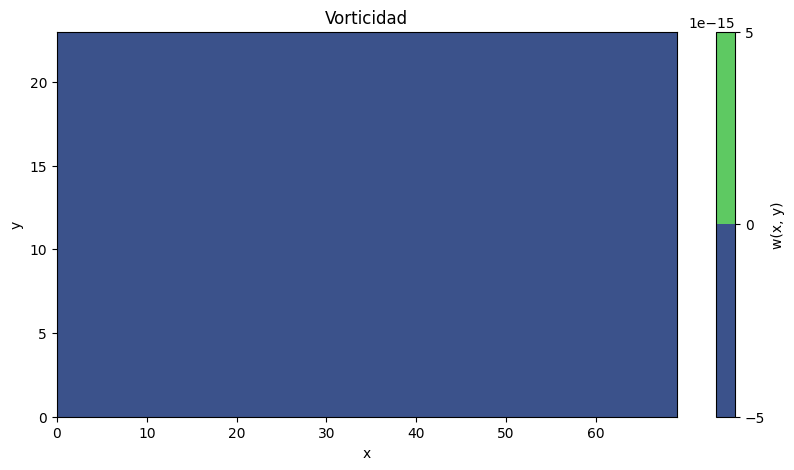

In [35]:
X, Y = np.meshgrid(np.arange(Nx), np.arange(Ny))

plt.figure(figsize = (10, 5))

plt.contourf(
    X, Y, w.T,
    levels = 40
)

plt.colorbar(label = r'w(x, y)')

plt.title('Vorticidad')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

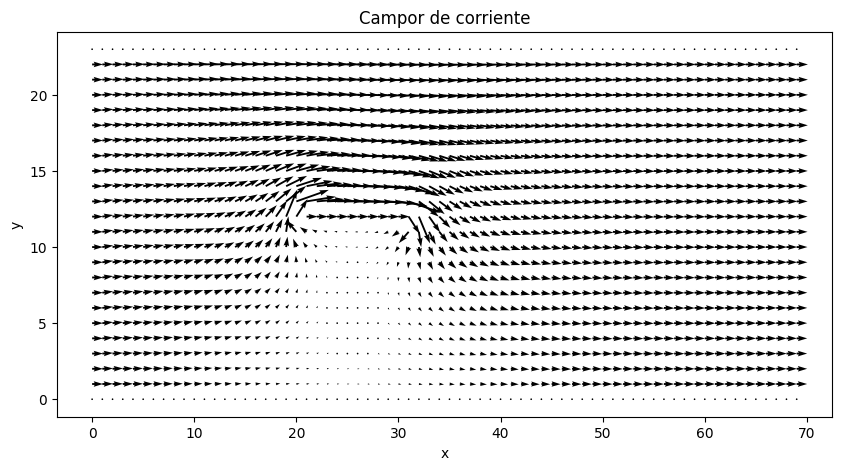

In [31]:
X, Y = np.meshgrid(np.arange(Nx), np.arange(Ny))

plt.figure(figsize = (10, 5))

plt.quiver(
    X, Y, vx.T, vy.T)

plt.title('Campor de corriente')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

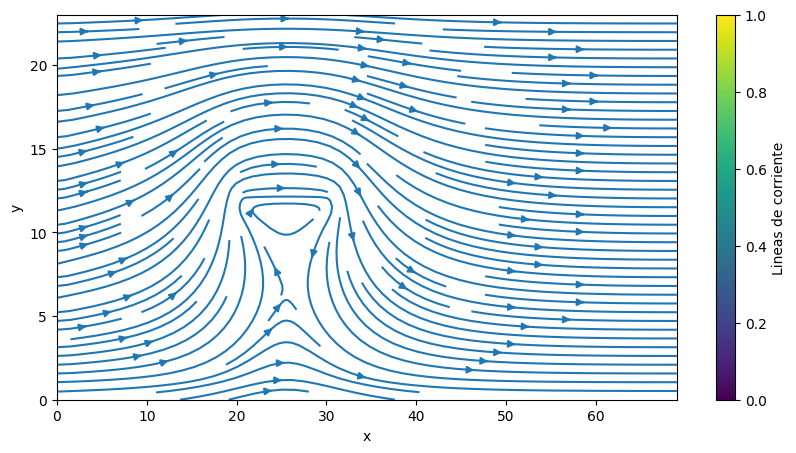

In [36]:
pltX, Y = np.meshgrid(np.arange(Nx), np.arange(Ny))

plt.figure(figsize = (10, 5))

plt.streamplot(
    X, Y, vx.T, vy.T,
    density = 1.5
)

plt.colorbar(label = r'Lineas de corriente')


plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
#condiciones de frontera
def apply_boundary():
    #Entrada (flujo uniforme)
    for j in range(Ny):
        u[0, j] = j * v0

    #salida (gradiente cero)
    for j in range(Ny):
        u[Nx - 1, j] = u[Nx -2, j]

    #superficie
    for i in range(Nx):
        u[i, Ny -1] = u[i, Ny - 2] + v0 * h

    #viga (no-slip)
    for i in range(beam_x_start, beam_x_end):
        u[i, beam_y] = 0


#relajación
def relax():
    u_old = u.copy()
    w_old = w.copy()

    #actualizar u
    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            r1 = 0.25 * (
                u[]
            )